# **Regression**

In [3]:
# loading data
import pandas as pd

df = pd.read_csv("emi_prediction_cleaned.csv")

print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['age', 'gender', 'marital_status', 'education', 'monthly_salary', 'employment_type', 'years_of_employment', 'company_type', 'house_type', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'existing_loans', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario', 'requested_amount', 'requested_tenure', 'emi_eligibility', 'max_monthly_emi']


In [4]:
# Check numerical columns
print("\nNumerical columns:")
print(df.select_dtypes(include=["int64", "float64"]).columns.tolist())


Numerical columns:
['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'emergency_fund', 'requested_amount', 'requested_tenure', 'max_monthly_emi']


In [5]:
# Check target candidates
print("\nDataset shape:")
print(df.shape)

print("\nNumerical column summary:")
display(df.select_dtypes(include=["int64", "float64"]).describe().T)


Dataset shape:
(388233, 27)

Numerical column summary:


,count,mean,std,min,25%,50%,75%,max
age,388233.0,38.879511,9.301626,26.0,32.0,38.00,48.0,59.0
monthly_salary,388233.0,59507.074700,43380.148137,3967.0,35400.0,51700.00,73000.0,499970.0
years_of_employment,388233.0,5.370930,6.087006,0.5,1.2,3.20,7.2,36.0
monthly_rent,388233.0,5830.243575,8648.138787,0.0,0.0,0.00,10600.0,80000.0
family_size,388233.0,2.941110,1.075098,1.0,2.0,3.00,4.0,5.0
dependents,388233.0,1.941110,1.075098,0.0,1.0,2.00,3.0,4.0
school_fees,388233.0,4625.229695,5061.387432,0.0,0.0,3000.00,9000.0,15000.0
college_fees,388233.0,4067.514611,7320.551029,0.0,0.0,0.00,6500.0,25000.0
travel_expenses,388233.0,5687.083272,3391.912235,600.0,3200.0,4900.00,7400.0,30300.0
groceries_utilities,388233.0,12806.037611,6992.172074,1800.0,7700.0,11400.00,16400.0,71200.0


# **Define the regression target**

In [6]:
# Regression target
target = "max_monthly_emi"

print("Target:", target)
print("Target dtype:", df[target].dtype)

print("\nTarget statistics:")
print(df[target].describe())

Target: max_monthly_emi
Target dtype: float64

Target statistics:
count    388233.000000
mean       6764.285901
std        7744.554738
min         500.000000
25%         500.000000
50%        4213.440000
75%        9792.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64


In [7]:
# Check categorical columns
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'bank_balance', 'emi_scenario', 'emi_eligibility']


In [8]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("\nNumerical columns:")
print(numerical_cols)


Numerical columns:
['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'emergency_fund', 'requested_amount', 'requested_tenure', 'max_monthly_emi']


**Separate X and Y**

In [9]:
# Separate features and target

target = "max_monthly_emi"

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget sample:")
print(y.head())

X shape: (388233, 26)
y shape: (388233,)

Target sample:
0      500.0
1      700.0
2    27775.0
3    16170.0
4      500.0
Name: max_monthly_emi, dtype: float64


**Remove the classification target**

Because emi_eligibility was classification target, we not use it as an input feature for this regression model.

In [10]:
if "emi_eligibility" in X.columns:
    X = X.drop(columns=["emi_eligibility"])

print("X shape after removing classification target:", X.shape)

X shape after removing classification target: (388233, 25)


**Train-Test Split**

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (310586, 25)
X_test : (77647, 25)
y_train: (310586,)
y_test : (77647,)


In [19]:
# Check NaN counts in original training data*

print("NaN values in X_train:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

print("\nNaN values in X_test:")
print(X_test.isna().sum()[X_test.isna().sum() > 0])

NaN values in X_train:
bank_balance    1488
dtype: int64

NaN values in X_test:
bank_balance    396
dtype: int64


In [20]:
from sklearn.impute import SimpleImputer

# Numerical columns
num_imputer = SimpleImputer(strategy="median")

# Recalculate numeric feature columns after removing the target.
# This also includes bank_balance after its numeric conversion.
numerical_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
numerical_cols = [column for column in numerical_cols if column != target]

X_train[numerical_cols] = num_imputer.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = num_imputer.transform(X_test[numerical_cols])

# Categorical columns
cat_imputer = SimpleImputer(strategy="most_frequent")

if categorical_cols:
    X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
    X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

print("Missing values after imputation:")
print("X_train:", X_train.isna().sum().sum())
print("X_test :", X_test.isna().sum().sum())

Missing values after imputation:
X_train: 0
X_test : 0


In [21]:
# create the encoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("X_train encoded shape:", X_train_encoded.shape)
print("X_test encoded shape :", X_test_encoded.shape)

X_train encoded shape: (310586, 49)
X_test encoded shape : (77647, 49)


In [22]:
import numpy as np

print("NaN count in X_train:",
      np.isnan(X_train_encoded.data).sum() if hasattr(X_train_encoded, "data") else np.isnan(X_train_encoded).sum())

print("NaN count in X_test:",
      np.isnan(X_test_encoded.data).sum() if hasattr(X_test_encoded, "data") else np.isnan(X_test_encoded).sum())

NaN count in X_train: 0
NaN count in X_test: 0


# First regression model
**Let's start with Linear Regression as the baseline:**

In [23]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_encoded, y_train)

y_pred_linear = linear_model.predict(X_test_encoded)

print("Linear Regression training completed!")

Linear Regression training completed!


In [24]:
# Evaluate 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("--------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Results
--------------------------
MAE : 2973.6077202187967
RMSE: 4128.557050714656
R²  : 0.7188117962553123


# Train Random Forest Regression

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_encoded, y_train)

y_pred_rf = rf_model.predict(X_test_encoded)

print("Random Forest Regression training completed!")

Random Forest Regression training completed!


In [26]:
# Evaluate Random Forest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Results")
print("---------------------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regression Results
---------------------------------
MAE : 770.6551504488261
RMSE: 1333.1386861870267
R²  : 0.9706808632224131


In [27]:
# Compare with Linear Regression
print("MODEL COMPARISON")
print("==============================")

print(f"Linear Regression  | MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.4f}")
print(f"Random Forest      | MAE: {mae_rf:.2f} | RMSE: {rmse_rf:.2f} | R²: {r2_rf:.4f}")

MODEL COMPARISON
Linear Regression  | MAE: 2973.61 | RMSE: 4128.56 | R²: 0.7188
Random Forest      | MAE: 770.66 | RMSE: 1333.14 | R²: 0.9707


# **XGBoost Regressor**

In [ ]:
# Import it
from xgboost import XGBRegressor

In [34]:
# Train XGBoost
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_encoded, y_train)

y_pred_xgb = xgb_model.predict(X_test_encoded)

print("XGBoost Regression training completed!")

XGBoost Regression training completed!


In [35]:
# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regression Results")
print("--------------------------")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost Regression Results
--------------------------
MAE : 846.4955058695945
RMSE: 1270.523640235691
R²  : 0.9733703157301726


In [36]:
# Adding MAPE
from sklearn.metrics import mean_absolute_percentage_error

mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb) * 100

print("MAPE:", mape_xgb, "%")

MAPE: 47.050780693929674 %


In [ ]:
# MAPE for all three models
mape_linear = mean_absolute_percentage_error(
    y_test, y_pred_linear
) * 100

mape_rf = mean_absolute_percentage_error(
    y_test, y_pred_rf
) * 100

mape_xgb = mean_absolute_percentage_error(
    y_test, y_pred_xgb
) * 100

print("Linear Regression MAPE:", mape_linear, "%")
print("Random Forest MAPE:", mape_rf, "%")
print("XGBoost MAPE:", mape_xgb, "%")

Linear Regression MAPE: 193.74166907108523 %
Random Forest MAPE: 22.533675841381925 %
XGBoost MAPE: 47.050780693929674 %


In [38]:
# Check actual vs predicted values
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf
})

print(comparison_df.head(10))

     Actual   Predicted
0  17350.00  16965.1500
1   9000.00   8456.1890
2   1584.00   2669.4400
3  23595.00  23677.4300
4   8073.45   8108.7195
5   1064.00    857.7376
6    500.00    500.0000
7  25960.00  23970.2600
8   9702.00   6939.7040
9  15660.00  15546.7820


In [39]:
# Calculate the Prediction Error
comparison_df["Error"] = (
    comparison_df["Actual"] - comparison_df["Predicted"]
)

print("\nError statistics:")
print(comparison_df["Error"].describe())


Error statistics:
count    77647.000000
mean       -15.019202
std       1333.062664
min     -12924.816000
25%       -475.442950
50%        -26.934100
75%        345.358500
max      33132.511000
Name: Error, dtype: float64


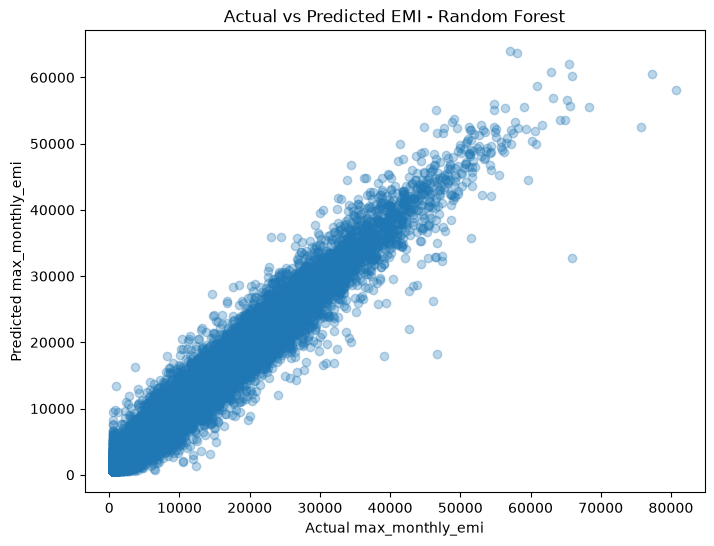

In [40]:
# Actual vs Predicted visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    comparison_df["Actual"],
    comparison_df["Predicted"],
    alpha=0.3
)

plt.xlabel("Actual max_monthly_emi")
plt.ylabel("Predicted max_monthly_emi")
plt.title("Actual vs Predicted EMI - Random Forest")

plt.show()

In [42]:
# Save the best regression model
import joblib

joblib.dump(xgb_model, "best_regression_model_xgb.pkl")
joblib.dump(preprocessor, "regression_preprocessor.pkl")

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [43]:
import os

print("XGBoost model exists:",
      os.path.exists("best_regression_model_xgb.pkl"))

print("Preprocessor exists:",
      os.path.exists("regression_preprocessor.pkl"))

XGBoost model exists: True
Preprocessor exists: True
